# P2: Análisis fonético

**Contenido del notebook.**
1. Generación de las cinco vocales del español por modelo fuente-filtro para tener un espacio $(F_1, F_2)$ controlado.
2. Diagrama $(F_1, F_2)$ y comparación con la predicción del ejercicio 1.
3. Lectura de espectrograma de una frase corta.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
from scipy.io import wavfile
from IPython.display import Audio, display
plt.rcParams['figure.figsize'] = (10, 4)
np.set_printoptions(precision=2, suppress=True)
np.random.seed(0)

## Ejercicio 3. Sintetizar las cinco vocales por modelo fuente-filtro

Generamos una aproximación de cada vocal mediante el modelo fuente-filtro. La fuente es un tren de pulsos con $F_0 = 120 \text{Hz}$. 

Aproximamos el tracto vocal mediante tres resonadores digitales amortiguados de segundo orden, uno por formante. Cada resonador es un filtro recursivo (IIR) todo-polo:

$$
H_i(z)=
\frac{1-r_i^2}
{1-2r_i\cos(\theta_i)z^{-1}+r_i^2z^{-2}},
\qquad i=1,2,3.
$$

Cada uno tiene un par de polos complejos conjugados:

$$
p_{i,\pm}=r_i e^{\pm j\theta_i},
\qquad
\theta_i=\frac{2\pi F_i}{f_s},
\qquad
r_i=e^{-\pi BW_i/f_s}.
$$

- El ángulo $\theta_i$ sitúa la resonancia cerca del formante $F_i$.
- El radio $r_i$ controla el amortiguamiento: ante un impulso, el resonador produce una oscilación cuya envolvente decae como $r_i^n$.
- El ancho de banda $BW_i$ determina cuán ancha es la resonancia. Un ancho menor corresponde a un radio más cercano a $1$; en ese caso la oscilación tarda más en apagarse y el pico espectral es más estrecho.

La relación entre $r_i$ y $BW_i$ sale de la aproximación habitual para resonancias estrechas (tomando el ancho de banda entre los puntos de media potencia aproximadamente a $-3 \text{dB}$ del pico).

La salida de cada resonador alimenta al siguiente. Por lo tanto, sus funciones de transferencia se multiplican:

$$
H(z)=H_1(z)H_2(z)H_3(z).
$$

Esto permite construir un único filtro todo-polo con las tres resonancias (de orden seis). Aclaramos que esto no significa que el tracto vocal tenga tres cavidades independientes.

Valores de formantes usados (referencia para español):

| Vocal | $F_1$ (Hz) | $F_2$ (Hz) | $F_3$ (Hz) |
|:------|-----------:|-----------:|-----------:|
| /a/   | 750        | 1300       | 2500       |
| /e/   | 450        | 2100       | 2700       |
| /i/   | 300        | 2300       | 3000       |
| /o/   | 500        | 1000       | 2500       |
| /u/   | 350        | 800        | 2300       |


In [19]:
fs = 16000
F0 = 120
duracion = 0.8

### COMPLETAR diccionario
formantes = {
    'a': [750, 1300, 2500],
    'e': [450, 2100, 2700],
    'i': [300, 2300, 3000],
    'o': [500, 1000, 2500],
    'u': [350, 800,  2300],
}
anchos_BW = [80, 90, 120]  # ancho de banda de cada formante (Hz)

def sintetizar_vocal(formant_freqs, fs, F0, duracion, bws):
    # Tren de pulsos como fuente glotal
    N_x = int(duracion * fs) # número de muestras
    n = np.arange(N_x)
    fuente = np.zeros(N_x)
    periodo = int(fs / F0)
    fuente[::periodo] = 1.0 #Tomas solos los elementos separados por "periodo"
    # Filtro: cascada de bicuadráticos, uno por formante
    salida = fuente.copy()
    for f, bw in zip(formant_freqs, bws):
        r = np.exp(-np.pi * bw / fs)  ### <-- COMPLETAR
        theta = 2 * np.pi * f / fs  ### <-- COMPLETAR
        # H(z) = (1 - r^2) / (1 - 2 r cos(theta) z^-1 + r^2 z^-2)
        b = [1 - r*r]
        a = [1, -2*r*np.cos(theta), r*r]
        salida = sig.lfilter(b, a, salida)  ### <-- COMPLETAR
    salida = salida / np.max(np.abs(salida)) 
    return salida


#Dos formas de hacerlo:
#vocales_audio = {v: sintetizar_vocal(formantes[v], fs, F0, duracion, anchos_BW) for v in formantes}
vocales_audio = {v: sintetizar_vocal(fk, fs, F0, duracion, anchos_BW) for v, fk in formantes.items()}


# Reproducir
for v, audio in vocales_audio.items():
    print(f'Vocal /{v}/  F1={formantes[v][0]} F2={formantes[v][1]} F3={formantes[v][2]}')
    display(Audio(audio, rate=fs))

Vocal /a/  F1=750 F2=1300 F3=2500


Vocal /e/  F1=450 F2=2100 F3=2700


Vocal /i/  F1=300 F2=2300 F3=3000


Vocal /o/  F1=500 F2=1000 F3=2500


Vocal /u/  F1=350 F2=800 F3=2300


In [11]:
import scipy.signal as sig sig.lfilter?

Signature: sig.lfilter(b, a, x, axis=-1, zi=None)
Docstring:
Filter data along one-dimension with an IIR or FIR filter.

Filter a data sequence, `x`, using a digital filter.  This works for many
fundamental data types (including Object type).  The filter is a direct
form II transposed implementation of the standard difference equation
(see Notes).

The function `sosfilt` (and filter design using ``output='sos'``) should be
preferred over `lfilter` for most filtering tasks, as second-order sections
have fewer numerical problems.

Parameters
----------
b : array_like
    The numerator coefficient vector in a 1-D sequence.
a : array_like
    The denominator coefficient vector in a 1-D sequence.  If ``a[0]``
    is not 1, then both `a` and `b` are normalized by ``a[0]``.
x : array_like
    An N-dimensional input array.
axis : int, optional
    The axis of the input data array along which to apply the
    linear filter. The filter is applied to each subarray along
    this axis.  Default is

## Ejercicio 4. Diagrama (F1, F2) y comparación con la predicción

Esta es la verificación visual del ejercicio 1.

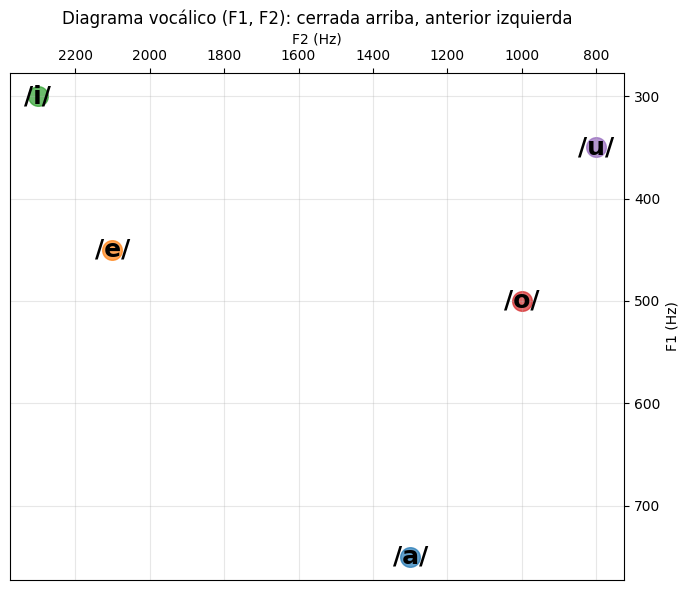

In [33]:
fig, ax = plt.subplots(figsize=(7, 6))

for v in ['a', 'e', 'i', 'o', 'u']:
    F1, F2 = formantes[v][0], formantes[v][1]

    ax.scatter(F2, F1, s=200, alpha=0.7)
    ax.annotate(
        f'/{v}/',
        (F2, F1),
        fontsize=18,
        ha='center',
        va='center',
        fontweight='bold'
    )

ax.set_xlabel('F2 (Hz)')
ax.set_ylabel('F1 (Hz)')

# Convención del diagrama vocálico:
# - F1 bajo = vocal cerrada -> arriba
# - F2 alto = vocal anterior -> izquierda
# - labels y ticks de F1 a la derecha
# - labels y ticks de F2 arriba
ax.invert_xaxis()
ax.invert_yaxis()
ax.xaxis.tick_top() 
ax.yaxis.tick_right()                          
ax.xaxis.set_label_position("top") 
ax.yaxis.set_label_position("right")

ax.set_title('Diagrama vocálico (F1, F2): cerrada arriba, anterior izquierda')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Comentarios:** <mark>COMPLETAR</mark>.

## Ejercicio 5. Espectrograma de una frase corta

Concatenamos vocales con duraciones realistas y miramos el espectrograma.

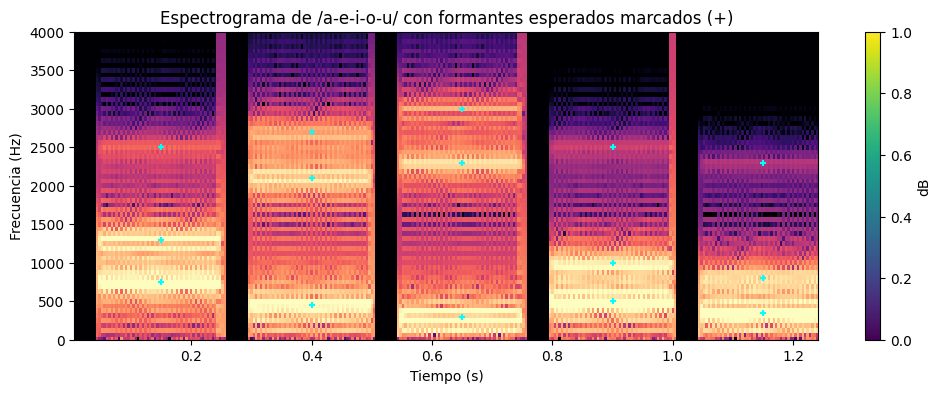

In [48]:
def silencio(duracion, fs):
    return np.zeros(int(duracion*fs))

# Frase sintetica: secuencia de vocales /a-e-i-o-u/
duracion_silencio = 0.05
duracion_vocal = 0.2
#Forma que no me salió
#frase = np.concatenate([
#    np.concatenate([silencio(duracion_silencio, fs), sintetizar_vocal(formantes[v], fs, F0, duracion_vocal, anchos_BW) for v in formantes])
#])

#FORMA KEVIN
frase = np.concatenate([
    silencio(duracion_silencio, fs),
    sintetizar_vocal(formantes['a'], fs, F0, duracion_vocal, anchos_BW),
    silencio(duracion_silencio, fs),
    sintetizar_vocal(formantes['e'], fs, F0, duracion_vocal, anchos_BW),
    silencio(duracion_silencio, fs),
    sintetizar_vocal(formantes['i'], fs, F0, duracion_vocal, anchos_BW),
    silencio(duracion_silencio, fs),
    sintetizar_vocal(formantes['o'], fs, F0, duracion_vocal, anchos_BW),
    silencio(duracion_silencio, fs),
    sintetizar_vocal(formantes['u'], fs, F0, duracion_vocal, anchos_BW),
])

display(Audio(frase, rate=fs))

f, t, S = sig.spectrogram(frase, fs=fs, nperseg=256, noverlap=192, scaling='spectrum')
plt.figure(figsize=(12, 4))
plt.pcolormesh(t, f, 10*np.log10(S + 1e-10), shading='auto', cmap='magma', vmin=-80, vmax=-20)
plt.ylim(0, 4000)
# Marcar formantes esperados
#Ojo que esta marca de formantes solo funciona para silencio = 0.05 y vocal = 0.2
for i, v in enumerate(['a', 'e', 'i', 'o', 'u']):
    tc = 0.15 + i*0.25
    for F in formantes[v]:
        if F < 4000:
            plt.scatter([tc], [F], color='cyan', s=20, marker='+')
plt.xlabel('Tiempo (s)')
plt.ylabel('Frecuencia (Hz)')
plt.title('Espectrograma de /a-e-i-o-u/ con formantes esperados marcados (+)')
plt.colorbar(label='dB')
plt.show()

**Lectura del espectrograma.**

- Separación bandas oscuras horizontales 120Hz
- Formantes marcados por los markers
- Coincide las posiciones de F1 y F2 del gráfico del punto anterior con el espectrograma
- Existen silencios equiespaciados según la duración de silencio

## Cierre

Esta práctica fija el vocabulario fonético acústico del curso. En la tercera práctica vamos a ver la implementación de los MFCC, que son la representación estándar para el resto de la materia.